In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Import required library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/cw1data.csv")

# Display general information about the dataset
print("Dataset Shape:", df.shape)
print("\n--- Dataset Information ---")
print(df.info())

# Display the first few rows
print("\n--- First 5 Rows ---")
print(df.head())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Generate sumary statistics
print("\n--- Summary Statistics ---")
print(df.describe())


Dataset Shape: (135, 14)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       135 non-null    float64
 1   x1      135 non-null    float64
 2   x2      135 non-null    float64
 3   x3      135 non-null    int64  
 4   x4      135 non-null    float64
 5   x5      135 non-null    float64
 6   x6      135 non-null    float64
 7   x7      135 non-null    float64
 8   x8      135 non-null    float64
 9   x9      135 non-null    float64
 10  x10     135 non-null    float64
 11  x11     135 non-null    float64
 12  x12     135 non-null    float64
 13  x13     135 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 14.9 KB
None

--- First 5 Rows ---
       y    x1     x2  x3     x4     x5     x6     x7     x8     x9    x10  \
0  49.83  1.68   82.8  24  6.554  6.538  6.438  6.390  6.318  29.44  39.83   
1  50.12  1.71

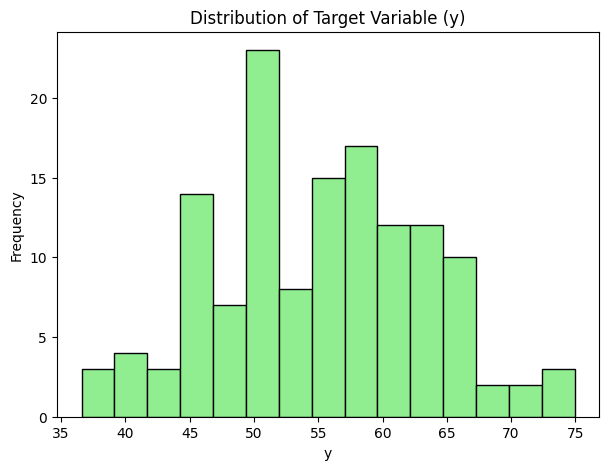

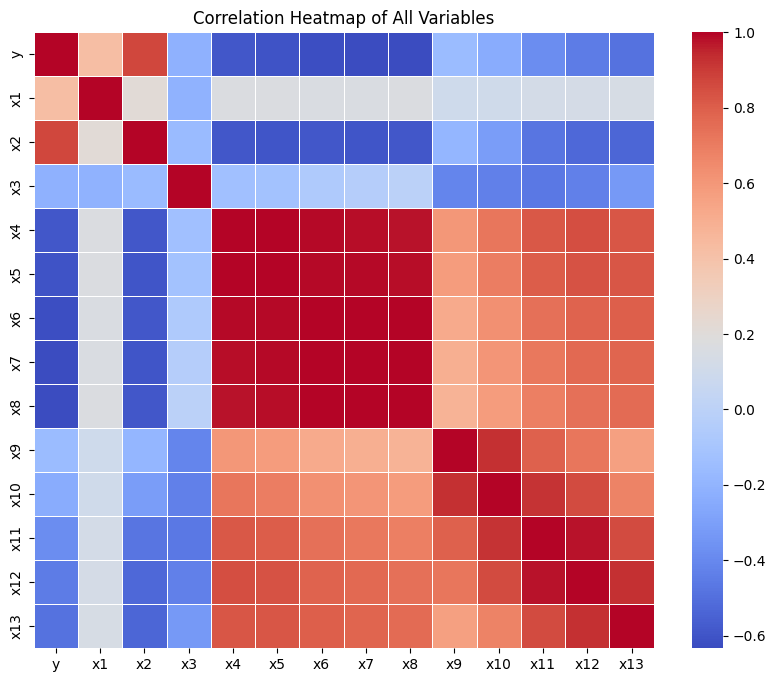

In [5]:



# - seaborn: for creating visually appealing statistical graphics
# - matplotlib: for building plots and customizing figures
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram of the target variable (y)
# This plot shows the distribution of the target variable 'y'.
# It helps identify the shape of the data (normal, skewed, etc.)
# and detect any outliers or extreme values.
# A roughly symmetric shape suggests normal distribution,
# while skewness may indicate the need for transformation.
plt.figure(figsize=(7,5))
plt.hist(df['y'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('y (Target Variable)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap for all features
# The correlation heatmap displays the relationships between
# all numeric variables in the dataset, including the target 'y'.
# Correlation values range from -1 to +1:
#   - +1 means a perfect positive linear relationship
#   - -1 means a perfect negative linear relationship
#   - 0 means no linear correlation
# By observing the heatmap, we can identify which features
# are strongly correlated with the target, which helps in
# feature selection for regression models.
plt.figure(figsize=(10,8))
corr_matrix = df.corr()  # Compute correlation matrix for all numeric columns
sns.heatmap(
    corr_matrix,
    annot=False,           # Set to True if you want numerical values shown
    cmap='coolwarm',       # Color map: red = positive, blue = negative
    linewidths=0.5         # Adds white lines between cells for readability
)
plt.title('Correlation Heatmap of All Variables')
plt.show()



In [6]:
# Import the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

# Define the input features (X) and target variable (y)
# Here, 'y' is the column we want to predict, while all other columns are predictors.
X = df.drop(columns=['y'])
y = df['y']

# Split the dataset into training and testing subsets
# test_size=0.2 means 20% of the data is used for testing, 80% for training.
# random_state=42 ensures the same split each time the code runs (for reproducibility).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display the dimensions of each subset
# This confirms that data was split correctly and both sets have matching row counts.
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (108, 13) (108,)
Testing set shape: (27, 13) (27,)


In [8]:


# Import the three regression algorithms from scikit-learn
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# 1. Create the models
# Linear Regression - basic model without regularization
# Lasso Regression - uses L1 regularization to shrink or remove less important features
# Ridge Regression - uses L2 regularization to reduce large coefficient values
lin_model = LinearRegression()
lasso_model = Lasso(alpha=0.1)
ridge_model = Ridge(alpha=1.0)

# 2. Train the models using the training data
# Each model learns the relationship between input features (X_train) and the target (y_train)
lin_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

# 3. Make predictions using the test data
# The trained models predict the target variable (y) for unseen data (X_test)
y_pred_lin = lin_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

# 4. Display sample predictions
# Showing the first few predicted values for each model as evidence of successful training
print("Linear Regression predictions:", y_pred_lin[:5])
print("Lasso Regression predictions:", y_pred_lasso[:5])
print("Ridge Regression predictions:", y_pred_ridge[:5])


Linear Regression predictions: [50.49926766 69.95682333 60.59607391 54.38917703 63.48180811]
Lasso Regression predictions: [53.00266039 69.06145895 56.98279474 57.43011541 65.62633774]
Ridge Regression predictions: [52.76394651 69.99403762 57.74839522 55.91045659 65.70945945]


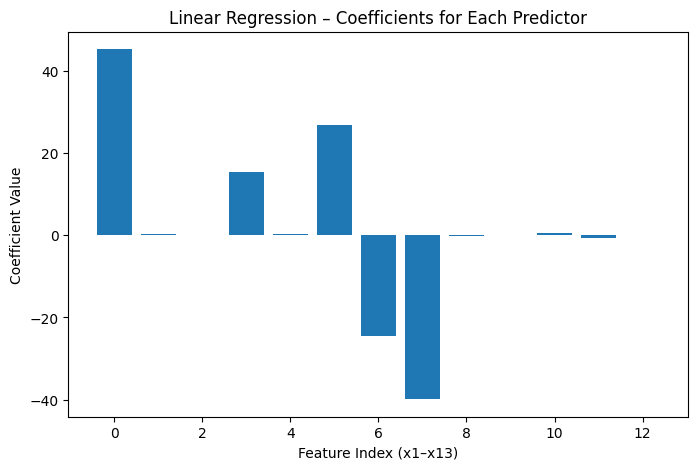

In [9]:
# Visualization for Linear Regression coefficients
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(range(len(lin_model.coef_)), lin_model.coef_)
plt.title('Linear Regression – Coefficients for Each Predictor')
plt.xlabel('Feature Index (x1–x13)')
plt.ylabel('Coefficient Value')
plt.show()


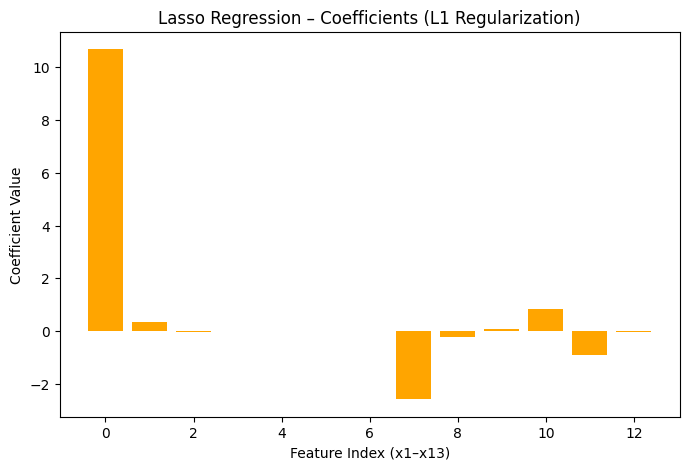

In [10]:
# Visualization for Lasso Regression coefficients
plt.figure(figsize=(8,5))
plt.bar(range(len(lasso_model.coef_)), lasso_model.coef_, color='orange')
plt.title('Lasso Regression – Coefficients (L1 Regularization)')
plt.xlabel('Feature Index (x1–x13)')
plt.ylabel('Coefficient Value')
plt.show()


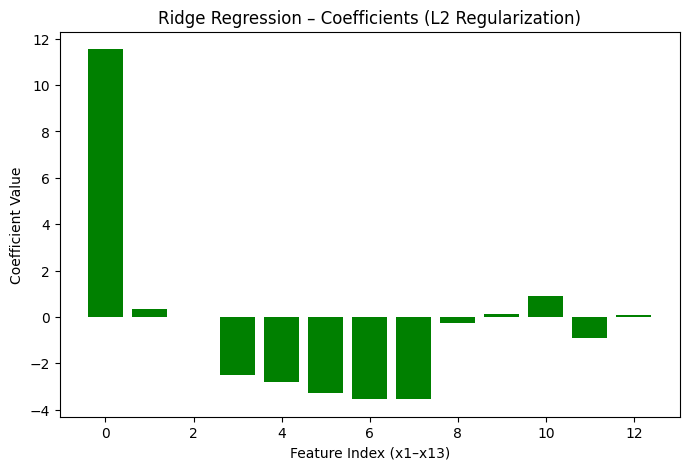

In [11]:
# Visualization for Ridge Regression coefficients
plt.figure(figsize=(8,5))
plt.bar(range(len(ridge_model.coef_)), ridge_model.coef_, color='green')
plt.title('Ridge Regression – Coefficients (L2 Regularization)')
plt.xlabel('Feature Index (x1–x13)')
plt.ylabel('Coefficient Value')
plt.show()


In [15]:

# Import evaluation metrics from scikit-learn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Define a helper function to calculate three key performance metrics for any model
def evaluate_model(y_true, y_pred):
    # RMSE (Root Mean Squared Error): the standard deviation of prediction errors
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAE (Mean Absolute Error): the average absolute error between predictions and actuals
    mae = mean_absolute_error(y_true, y_pred)
    # R² (Coefficient of Determination): how much of the target’s variance is explained by the model
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Evaluate each regression model using the test set results
# This step compares predicted values against actual test labels
lin_scores = evaluate_model(y_test, y_pred_lin)
lasso_scores = evaluate_model(y_test, y_pred_lasso)
ridge_scores = evaluate_model(y_test, y_pred_ridge)

# Combine all model scores into a single table (DataFrame) for easier comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'RMSE': [lin_scores[0], lasso_scores[0], ridge_scores[0]],
    'MAE': [lin_scores[1], lasso_scores[1], ridge_scores[1]],
    'R²': [lin_scores[2], lasso_scores[2], ridge_scores[2]]
})

# Display the table of evaluation results
print(results)


               Model      RMSE       MAE        R²
0  Linear Regression  2.731809  2.318318  0.882120
1   Lasso Regression  3.472215  2.522788  0.809563
2   Ridge Regression  3.337315  2.484392  0.824072


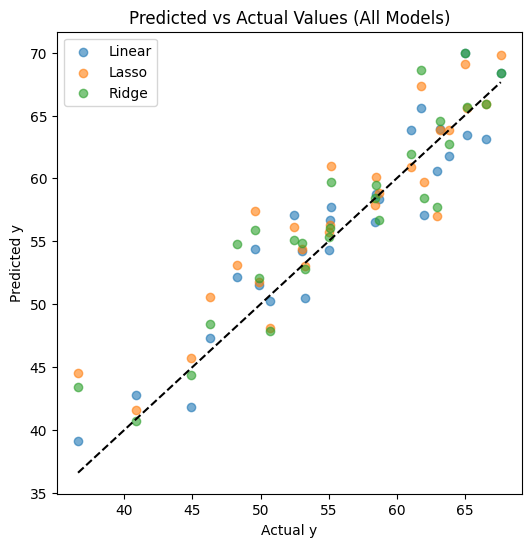

In [13]:
# Predicted vs Actual Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.6, label='Linear')
plt.scatter(y_test, y_pred_lasso, alpha=0.6, label='Lasso')
plt.scatter(y_test, y_pred_ridge, alpha=0.6, label='Ridge')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Predicted vs Actual Values (All Models)')
plt.legend()
plt.show()


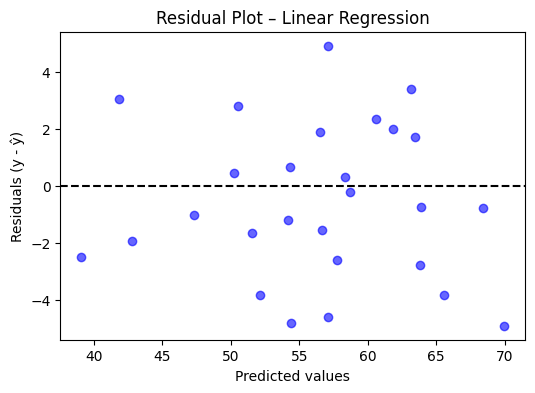

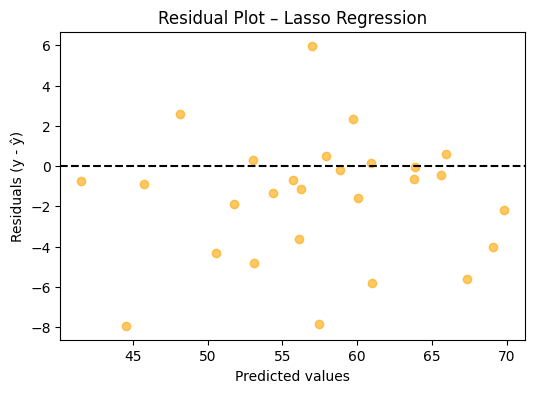

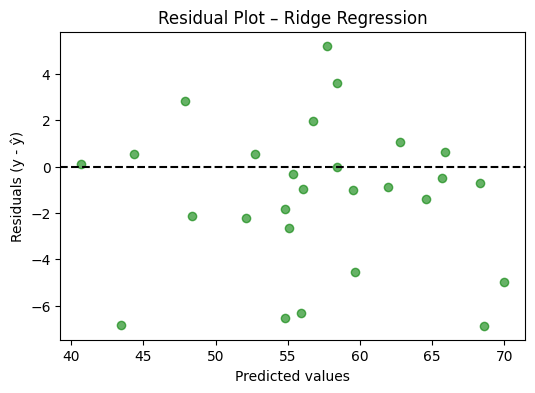

In [14]:
# Residual Plots for Each Model

# Linear Regression Residuals
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lin, y_test - y_pred_lin, alpha=0.6, color='blue')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot – Linear Regression')
plt.xlabel('Predicted values')
plt.ylabel('Residuals (y - ŷ)')
plt.show()

# Lasso Regression Residuals
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lasso, y_test - y_pred_lasso, alpha=0.6, color='orange')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot – Lasso Regression')
plt.xlabel('Predicted values')
plt.ylabel('Residuals (y - ŷ)')
plt.show()

# Ridge Regression Residuals
plt.figure(figsize=(6,4))
plt.scatter(y_pred_ridge, y_test - y_pred_ridge, alpha=0.6, color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot – Ridge Regression')
plt.xlabel('Predicted values')
plt.ylabel('Residuals (y - ŷ)')
plt.show()


In [17]:
from sklearn.preprocessing import StandardScaler

#Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Re-train the regularized models on scaled data
lasso_scaled = Lasso(alpha=0.1)
ridge_scaled = Ridge(alpha=1.0)

lasso_scaled.fit(X_train_scaled, y_train)
ridge_scaled.fit(X_train_scaled, y_train)

#Make predictions and evaluate
y_pred_lasso_scaled = lasso_scaled.predict(X_test_scaled)
y_pred_ridge_scaled = ridge_scaled.predict(X_test_scaled)

lasso_scaled_scores = evaluate_model(y_test, y_pred_lasso_scaled)
ridge_scaled_scores = evaluate_model(y_test, y_pred_ridge_scaled)

print("Lasso (Scaled):", lasso_scaled_scores)
print("Ridge (Scaled):", ridge_scaled_scores)


Lasso (Scaled): (np.float64(2.751946612603884), 2.404549207311557, 0.8803757400831328)
Ridge (Scaled): (np.float64(2.754492168605628), 2.35506927212907, 0.880154332380178)
